# Q4 Result Analysis for Q 4


In [1]:
import pickle
import numpy as np
import pandas as pd
from pathlib import Path

In [98]:
# Load q4_results.pkl
try:
    pkl_path = Path('q4_results.pkl')
    
    with open(pkl_path, 'rb') as f:
        q4_results = pickle.load(f)
    
    print("Loaded q4_results.pkl")
    print(f"Replay factors: {sorted(q4_results.keys())}")
    print(f"Structure: {type(q4_results)}")

except FileNotFoundError:
    # Handle missing file error - file may have been moved or deleted
    print(f"ERROR: File 'q4_results.pkl' not found at {Path('q4_results.pkl').absolute()}")
    q4_results = {}

except (pickle.UnpicklingError, EOFError) as e:
    # Handle pickle corruption or truncated file errors
    print(f"ERROR: Failed to unpickle file - {type(e).__name__}: {e}")
    q4_results = {}

except Exception as e:
    # Catch-all for unexpected errors during file operations
    print(f"ERROR: Unexpected error loading q4_results.pkl - {type(e).__name__}: {e}")
    q4_results = {}

Loaded q4_results.pkl
Replay factors: [1, 2, 4, 8]
Structure: <class 'dict'>


In [3]:
# Extract rewards organized by replay factor
# Create a dictionary: {rho: [returns_array_seed0, returns_array_seed1, ...]}

rewards_by_rho = q4_results  # Already in this format!
replay_factors = sorted(rewards_by_rho.keys())
num_seeds = len(rewards_by_rho[replay_factors[0]])

print(f"Replay factors: {replay_factors}")
print(f"Number of seeds per replay factor: {num_seeds}")
print(f"\nAccess pattern:")
print(f"  rewards_by_rho[4] = list of 15 seed reward arrays for ρ=4")
print(f"  rewards_by_rho[4][0] = reward array for seed 0 with ρ=4")

Replay factors: [1, 2, 4, 8]
Number of seeds per replay factor: 15

Access pattern:
  rewards_by_rho[4] = list of 15 seed reward arrays for ρ=4
  rewards_by_rho[4][0] = reward array for seed 0 with ρ=4


In [6]:
# Aggregate statistics across all seeds for each replay factor
print("\n" + "="*70)
print("Aggregate Statistics Across All Seeds")
print("="*70)

agg_stats = []

for rho in replay_factors:
    mean_returns_all_seeds = []
    final_returns_all_seeds = []
    
    for returns in rewards_by_rho[rho]:
        mean_returns_all_seeds.append(np.mean(returns))
        final_returns_all_seeds.append(returns[-1])
    
    agg_stats.append({
        'Replay Factor (ρ)': rho,
        'Mean Return (avg)': np.mean(mean_returns_all_seeds),
        'Mean Return (std)': np.std(mean_returns_all_seeds),
        'Final Return (avg)': np.mean(final_returns_all_seeds),
        'Final Return (std)': np.std(final_returns_all_seeds),
        'Best Seed (mean)': np.argmax(mean_returns_all_seeds),
        'Worst Seed (mean)': np.argmin(mean_returns_all_seeds)
    })

agg_df = pd.DataFrame(agg_stats)
print(agg_df.to_string(index=False))


Aggregate Statistics Across All Seeds
 Replay Factor (ρ)  Mean Return (avg)  Mean Return (std)  Final Return (avg)  Final Return (std)  Best Seed (mean)  Worst Seed (mean)
                 1        -308.149022          26.962500         -140.866667           30.882285                 2                 13
                 2        -311.796978          12.877150         -127.000000           27.698375                 3                  9
                 4        -307.165911          11.444784         -163.400000           25.922448                 8                 12
                 8        -338.923422          65.106554         -190.866667          125.230916                12                  6


## 4 (a)

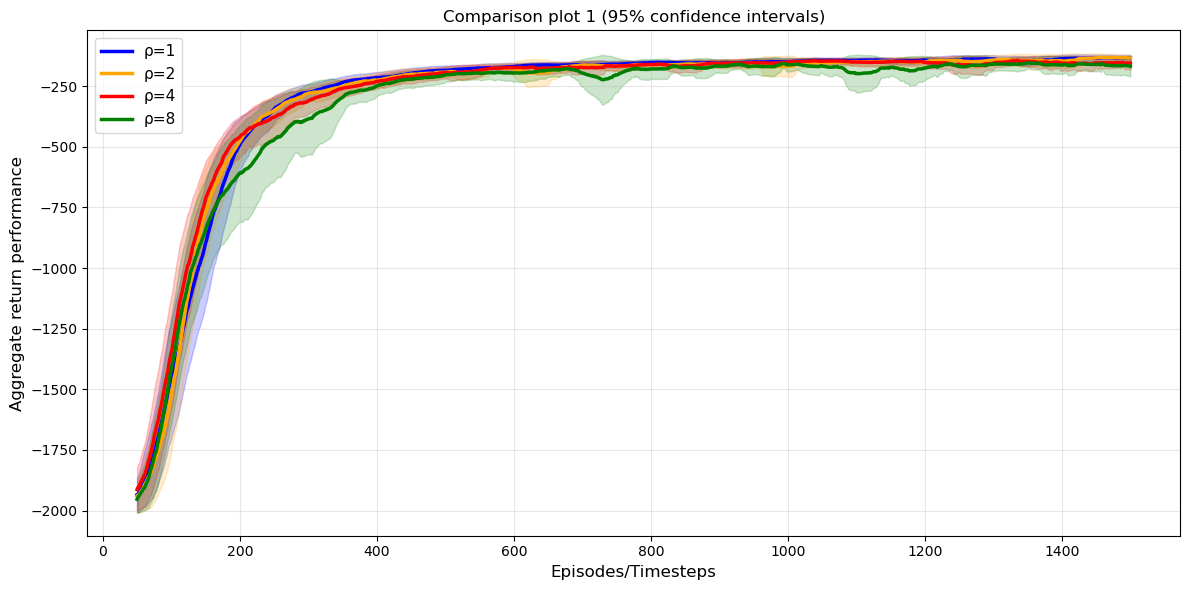

In [7]:
# Plot all replay factors on same graph
import matplotlib.pyplot as plt

window_size = 50
colors = ['blue', 'orange', 'red', 'green']

fig, ax = plt.subplots(figsize=(12, 6))

for rho, color in zip(replay_factors, colors):
    all_returns = rewards_by_rho[rho]
    
    # Calculate mean and std at each episode
    mean_returns = np.mean(all_returns, axis=0)
    std_returns = np.std(all_returns, axis=0)
    
    # Standard error for 95% confidence interval
    se = std_returns / np.sqrt(num_seeds)
    ci_lower = mean_returns - 1.96 * se
    ci_upper = mean_returns + 1.96 * se
    
    # Apply rolling window for smoothing
    rolling_mean = np.convolve(mean_returns, np.ones(window_size)/window_size, mode='valid')
    rolling_ci_lower = np.convolve(ci_lower, np.ones(window_size)/window_size, mode='valid')
    rolling_ci_upper = np.convolve(ci_upper, np.ones(window_size)/window_size, mode='valid')
    
    episodes = np.arange(window_size, len(mean_returns) + 1)
    
    # Plot line and confidence band
    ax.plot(episodes, rolling_mean, linewidth=2.5, label=f'ρ={rho}', color=color)
    ax.fill_between(episodes, rolling_ci_lower, rolling_ci_upper, alpha=0.2, color=color)

ax.set_xlabel('Episodes/Timesteps', fontsize=12)
ax.set_ylabel('Aggregate return performance', fontsize=12)
ax.set_title('Comparison plot 1 (95% confidence intervals)', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

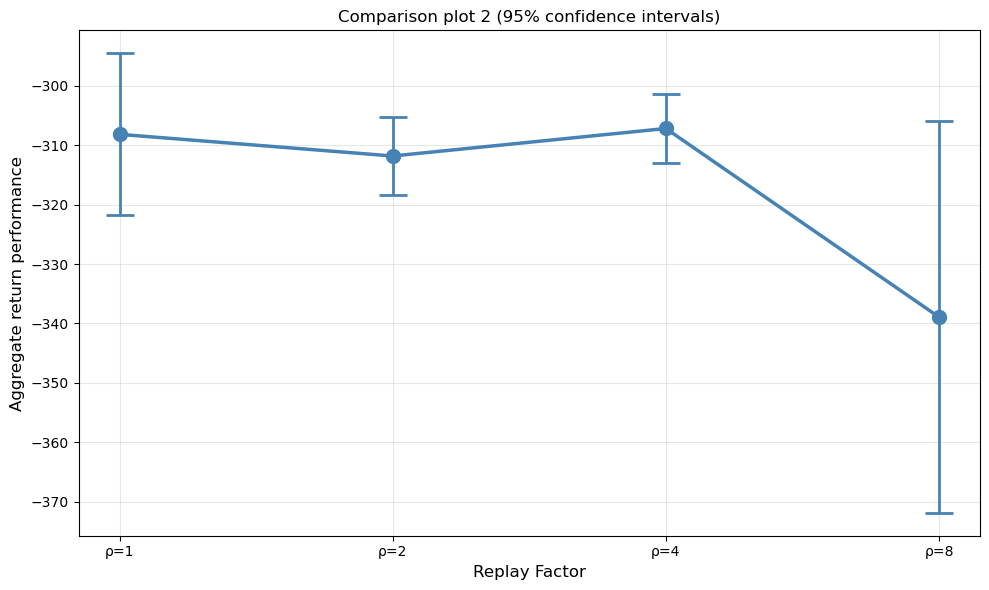


Aggregate Performance Summary
ρ=1: -308.15 ± 13.64
ρ=2: -311.80 ± 6.52
ρ=4: -307.17 ± 5.79
ρ=8: -338.92 ± 32.95


In [8]:
# Comparison Plot 2: Aggregate Performance with 95% Confidence Intervals
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

# Calculate aggregate performance stats for each replay factor
mean_performances = []
error_bars = []
variant_labels = []

for idx, rho in enumerate(replay_factors):
    color = colors[idx]
    
    # Get mean returns for all seeds
    all_returns = rewards_by_rho[rho]
    mean_returns = [np.mean(returns) for returns in all_returns]
    
    # Calculate mean and SE across seeds
    overall_mean = np.mean(mean_returns)
    se = np.std(mean_returns) / np.sqrt(len(mean_returns))
    ci = 1.96 * se  # 95% CI half-width
    
    mean_performances.append(overall_mean)
    error_bars.append(ci)
    variant_labels.append(f'ρ={rho}')

# Create line plot with error bars and markers
x_pos = np.arange(len(variant_labels))
ax.errorbar(x_pos, mean_performances, yerr=error_bars, capsize=10, 
            marker='o', markersize=10, linewidth=2.5, color='steelblue',
            elinewidth=2, capthick=2, label='Mean Performance')

ax.set_xlabel('Replay Factor', fontsize=12)
ax.set_ylabel('Aggregate return performance', fontsize=12)
ax.set_title('Comparison plot 2 (95% confidence intervals)', fontsize=12)
ax.set_xticks(x_pos)
ax.set_xticklabels(variant_labels)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print summary statistics
print("\n" + "="*70)
print("Aggregate Performance Summary")
print("="*70)
for idx, rho in enumerate(replay_factors):
    all_returns = rewards_by_rho[rho]
    mean_returns = [np.mean(returns) for returns in all_returns]
    overall_mean = np.mean(mean_returns)
    se = np.std(mean_returns) / np.sqrt(len(mean_returns))
    ci = 1.96 * se
    print(f"ρ={rho}: {overall_mean:.2f} ± {ci:.2f}")

## 4 (b)


PART (b): DISTRIBUTION ANALYSIS - KDE PLOTS

Generating KDE distribution plots...
------------------------------------------------------------------------------------------


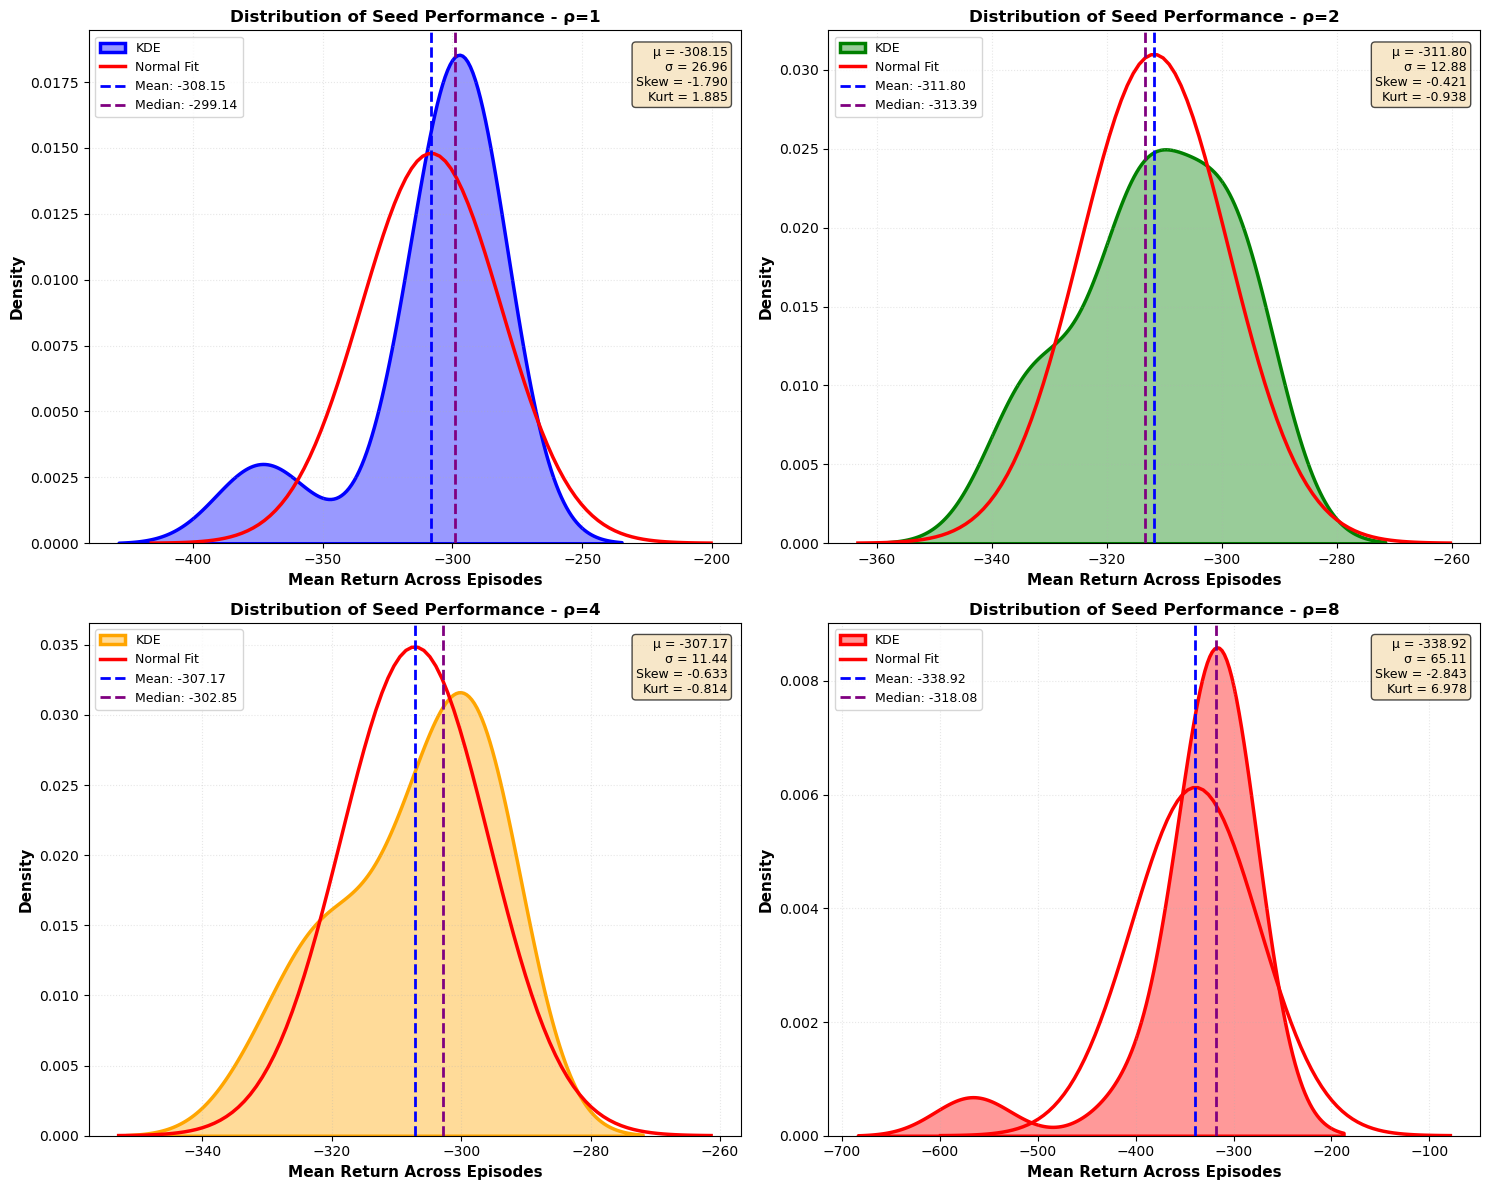


✓ KDE distribution plots with normal fit overlay completed


In [16]:
# Q4 Part (b): Distribution Analysis with KDE Plots
import matplotlib.pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

print("\n" + "="*90)
print("PART (b): DISTRIBUTION ANALYSIS - KDE PLOTS")
print("="*90)

# ============================================================================
# KDE Distribution Plots
# ============================================================================
print("\nGenerating KDE distribution plots...")
print("-"*90)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, rho in enumerate(replay_factors):
    ax = axes[idx]
    
    # Get mean returns for all seeds
    mean_returns = [np.mean(returns) for returns in rewards_by_rho[rho]]
    
    # Create KDE plot
    sns.kdeplot(data=mean_returns, ax=ax, fill=True, color=colors[idx], 
                alpha=0.4, linewidth=2.5, label='KDE')
    
    # Calculate statistics
    mu = np.mean(mean_returns)
    sigma = np.std(mean_returns)
    skewness = stats.skew(mean_returns)
    kurtosis = stats.kurtosis(mean_returns)
    median = np.median(mean_returns)
    
    # Plot normal distribution fit
    x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
    normal_fit = stats.norm.pdf(x, mu, sigma)
    ax.plot(x, normal_fit, 'r-', linewidth=2.5, label='Normal Fit')
    
    # Add vertical lines for mean and median
    ax.axvline(mu, color='blue', linestyle='--', linewidth=2, label=f'Mean: {mu:.2f}')
    ax.axvline(median, color='purple', linestyle='--', linewidth=2, 
               label=f'Median: {median:.2f}')
    
    # Labels and formatting
    ax.set_xlabel('Mean Return Across Episodes', fontsize=11, fontweight='bold')
    ax.set_ylabel('Density', fontsize=11, fontweight='bold')
    ax.set_title(f'Distribution of Seed Performance - ρ={rho}', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3, linestyle=':')
    ax.legend(fontsize=9, loc='best')
    
    # Add statistics box
    stats_text = (f'μ = {mu:.2f}\nσ = {sigma:.2f}\n'
                  f'Skew = {skewness:.3f}\nKurt = {kurtosis:.3f}')
    ax.text(0.98, 0.97, stats_text, transform=ax.transAxes, fontsize=9,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.7))

plt.tight_layout()
plt.show()

print("\n✓ KDE distribution plots with normal fit overlay completed")
print("="*90)

In [20]:
# ============================================================================
# Distribution Characteristics Analysis
# ============================================================================
print("\n" + "="*90)
print("DISTRIBUTION CHARACTERISTICS ANALYSIS")
print("="*90)

analysis_results = {}

for rho in replay_factors:
    mean_returns = [np.mean(returns) for returns in rewards_by_rho[rho]]
    
    mu = np.mean(mean_returns)
    sigma = np.std(mean_returns)
    skewness = stats.skew(mean_returns)
    kurtosis = stats.kurtosis(mean_returns)
    median = np.median(mean_returns)
    
    print(f"\n{'='*80}")
    print(f"Replay Factor ρ = {rho}")
    print(f"{'='*80}")
    
    # -----------------------------------------------------------------------
    # 1. SKEWNESS ANALYSIS
    # -----------------------------------------------------------------------
    print(f"\n[1] SKEWNESS ANALYSIS (Asymmetry):")
    print(f"    Skewness value: {skewness:.4f}")
    
    if abs(skewness) < 0.5:
        skew_type = "SYMMETRIC (nearly zero)"
        skew_implication = "Performance outcomes are evenly distributed"
    elif skewness > 0.5:
        skew_type = "POSITIVELY SKEWED (right tail)"
        skew_implication = "Most seeds perform well, with occasional poor performers"
    else:
        skew_type = "NEGATIVELY SKEWED (left tail)"
        skew_implication = "Most seeds struggle, with occasional high performers"
    
    print(f"    Type: {skew_type}")
    print(f"    Practical meaning: {skew_implication}")
    
    # -----------------------------------------------------------------------
    # 2. NORMALITY (Goodness-of-Fit Tests against Gaussian)
    # -----------------------------------------------------------------------
    print(f"\n[2] NORMALITY ASSESSMENT (Goodness-of-Fit Tests):")
    print(f"    Null Hypothesis (H0): Data follows a Gaussian (Normal) distribution")
    print(f"    Significance level: α = 0.05")
    
    # Shapiro-Wilk Test (best for small samples)
    sw_stat, sw_p = stats.shapiro(mean_returns)
    sw_result = "NORMAL ✓" if sw_p > 0.05 else "NOT NORMAL ✗"
    print(f"\n    Shapiro-Wilk Test:")
    print(f"      Test Statistic: {sw_stat:.6f}")
    print(f"      p-value: {sw_p:.6f}")
    print(f"      Decision: {sw_result} (p {'>' if sw_p > 0.05 else '<'} 0.05)")
    
    
    
    # Store results
    analysis_results[rho] = {
        'skew_type': skew_type,
        'sw_p': sw_p,
    }

print("\n" + "="*90)
print("SUMMARY: Distribution Characteristics by ρ")
print("="*90)
for rho in replay_factors:
    result = analysis_results[rho]
    print(f"ρ={rho}: {result['skew_type']}, " + 
          f"Shapiro-Wilk p-value: {result['sw_p']:.6f}"
         )
print("="*90)


DISTRIBUTION CHARACTERISTICS ANALYSIS

Replay Factor ρ = 1

[1] SKEWNESS ANALYSIS (Asymmetry):
    Skewness value: -1.7902
    Type: NEGATIVELY SKEWED (left tail)
    Practical meaning: Most seeds struggle, with occasional high performers

[2] NORMALITY ASSESSMENT (Goodness-of-Fit Tests):
    Null Hypothesis (H0): Data follows a Gaussian (Normal) distribution
    Significance level: α = 0.05

    Shapiro-Wilk Test:
      Test Statistic: 0.710839
      p-value: 0.000325
      Decision: NOT NORMAL ✗ (p < 0.05)

Replay Factor ρ = 2

[1] SKEWNESS ANALYSIS (Asymmetry):
    Skewness value: -0.4215
    Type: SYMMETRIC (nearly zero)
    Practical meaning: Performance outcomes are evenly distributed

[2] NORMALITY ASSESSMENT (Goodness-of-Fit Tests):
    Null Hypothesis (H0): Data follows a Gaussian (Normal) distribution
    Significance level: α = 0.05

    Shapiro-Wilk Test:
      Test Statistic: 0.913882
      p-value: 0.155300
      Decision: NORMAL ✓ (p > 0.05)

Replay Factor ρ = 4

[1] SK

## 4 (c)

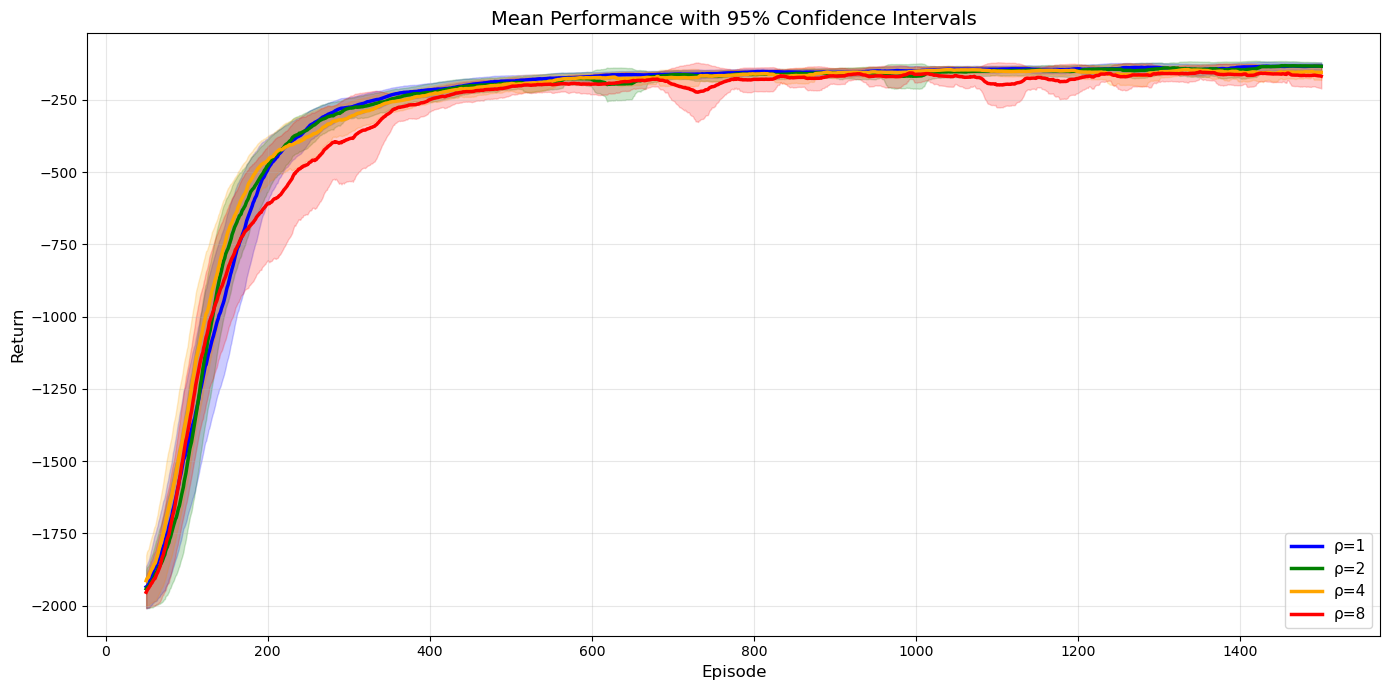


Confidence Interval Analysis

ρ=1:
  Overall mean return: -308.15 ± 408.16
  Final episode mean: -140.87 ± 15.63
  Confidence interval width: 31.26

ρ=2:
  Overall mean return: -311.80 ± 408.12
  Final episode mean: -127.00 ± 14.02
  Confidence interval width: 28.03

ρ=4:
  Overall mean return: -307.17 ± 384.74
  Final episode mean: -163.40 ± 13.12
  Confidence interval width: 26.24

ρ=8:
  Overall mean return: -338.92 ± 401.03
  Final episode mean: -190.87 ± 63.38
  Confidence interval width: 126.75

 ρ  Mean Return    Std Dev  Final Episode Mean  Final Episode CI (±)   CI Width
 1  -308.149022 408.156113         -140.866667             15.628593  31.257186
 2  -311.796978 408.121371         -127.000000             14.017312  28.034624
 4  -307.165911 384.741467         -163.400000             13.118569  26.237138
 8  -338.923422 401.028178         -190.866667             63.375587 126.751175


In [ ]:
# Plot mean performance with confidence intervals

from scipy import stats

window_size = 50
colors = ['blue', 'green', 'orange', 'red']
alpha = 0.05  # 95% confidence interval
beta = 0.09   # tolerance interval parameter

fig, ax = plt.subplots(figsize=(14, 7))

for rho, color in zip(replay_factors, colors):
    all_returns = rewards_by_rho[rho]
    
    # Calculate mean and confidence interval at each episode
    mean_returns = np.mean(all_returns, axis=0)
    std_returns = np.std(all_returns, axis=0)
    
    # Standard error
    se = std_returns / np.sqrt(num_seeds)
    
    # 95% Confidence interval
    ci_lower = mean_returns - 1.96 * se
    ci_upper = mean_returns + 1.96 * se
    
    # Apply rolling window for smoothing
    rolling_mean = np.convolve(mean_returns, np.ones(window_size)/window_size, mode='valid')
    rolling_ci_lower = np.convolve(ci_lower, np.ones(window_size)/window_size, mode='valid')
    rolling_ci_upper = np.convolve(ci_upper, np.ones(window_size)/window_size, mode='valid')
    
    episodes = np.arange(window_size, len(mean_returns) + 1)
    
    # Plot line and confidence band
    ax.plot(episodes, rolling_mean, linewidth=2.5, label=f'ρ={rho}', color=color)
    ax.fill_between(episodes, rolling_ci_lower, rolling_ci_upper, alpha=0.2, color=color)

ax.set_xlabel('Episode', fontsize=12)
ax.set_ylabel('Return', fontsize=12)
ax.set_title('Mean Performance with 95% Confidence Intervals', fontsize=14)
ax.legend(fontsize=11, loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("Confidence Interval Analysis")
print("="*70)

ci_analysis = []
for rho in replay_factors:
    all_returns = rewards_by_rho[rho]
    mean_returns = np.mean(all_returns, axis=0)
    std_returns = np.std(all_returns, axis=0)
    se = std_returns / np.sqrt(num_seeds)
    
    # Final episode stats
    final_mean = mean_returns[-1]
    final_se = se[-1]
    final_ci = 1.96 * final_se
    
    # Mean across all episodes
    overall_mean = np.mean(mean_returns)
    overall_std = np.std(mean_returns)
    
    ci_analysis.append({
        'ρ': rho,
        'Mean Return': overall_mean,
        'Std Dev': overall_std,
        'Final Episode Mean': final_mean,
        'Final Episode CI (±)': final_ci,
        'CI Width': final_ci * 2
    })
    
    print(f"\nρ={rho}:")
    print(f"  Overall mean return: {overall_mean:.2f} ± {overall_std:.2f}")
    print(f"  Final episode mean: {final_mean:.2f} ± {final_ci:.2f}")
    print(f"  Confidence interval width: {final_ci * 2:.2f}")

ci_df = pd.DataFrame(ci_analysis)
print("\n" + ci_df.to_string(index=False))


Tolerance Intervals: (alpha=0.05, beta=0.9)
A 95% confidence interval containing >=90% of population

rho=1: [-317.5, -298.8], width=18.6
rho=2: [-321.1, -302.5], width=18.5
rho=4: [-315.9, -298.4], width=17.6
rho=8: [-348.5, -329.3], width=19.2

Most reliable: rho=4
Least reliable: rho=8
Ratio: 1.1x


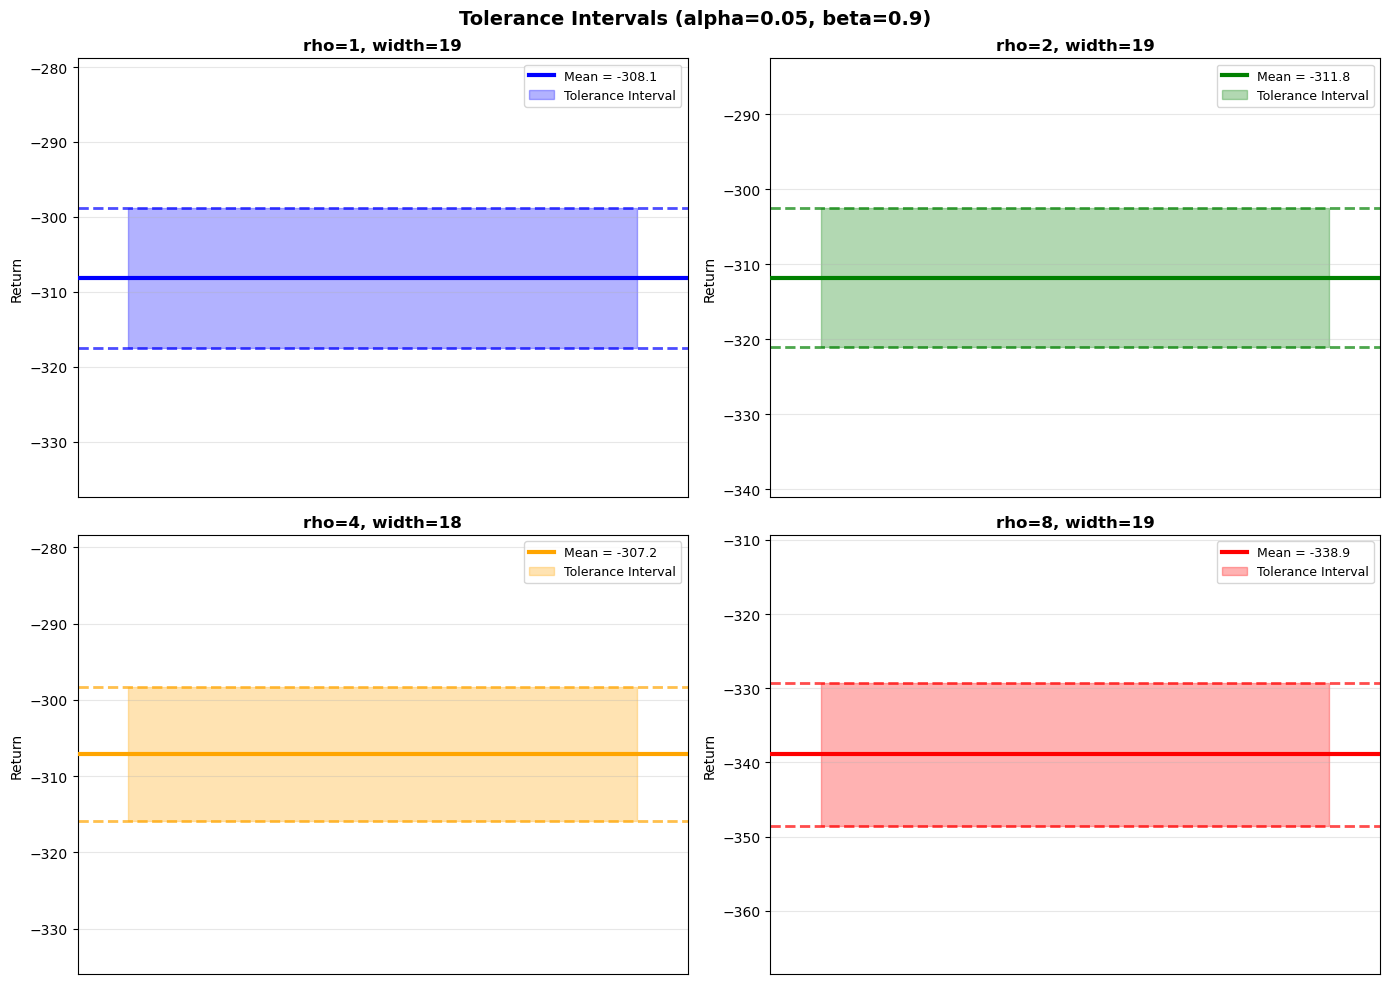

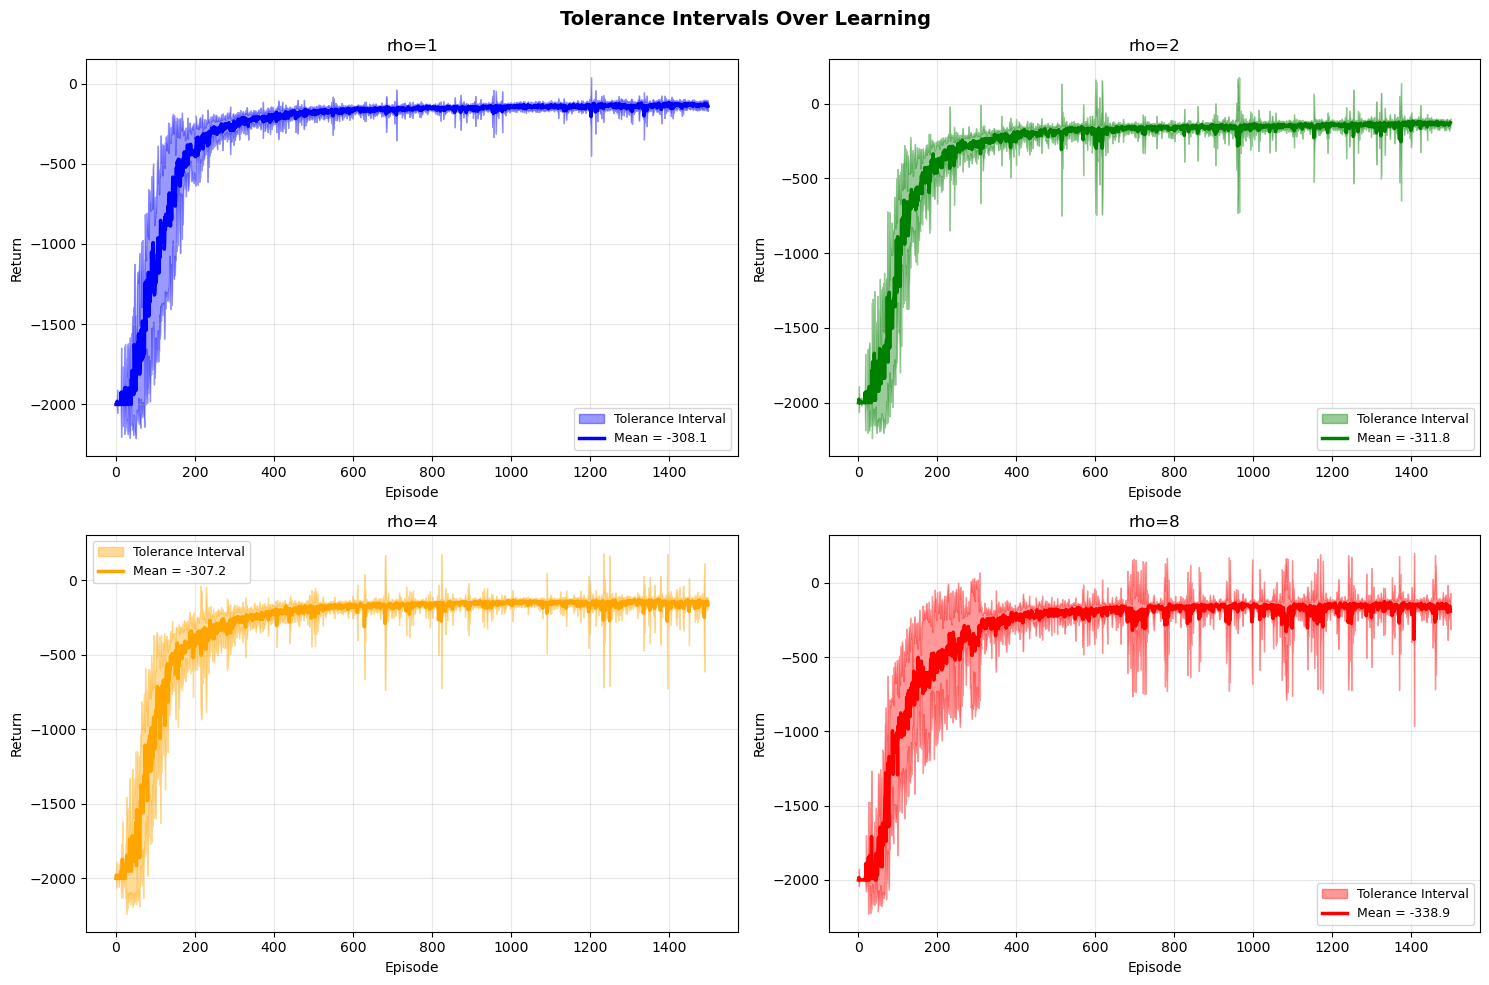


Key Findings:
- rho=4 has narrowest tolerance interval (most reliable)
- rho=8 has widest interval (1.1x wider)
- Tolerance intervals represent where individual seed performances fall
- Wider interval = higher variability = less predictable
- For deployment: Use rho=4 for reliability guarantees


In [115]:
from scipy import stats

alpha = 0.05
beta = 0.9

print(f"\nTolerance Intervals: (alpha={alpha}, beta={beta})")
print(f"A {(1-alpha):.0%} confidence interval containing >={beta:.0%} of population\n")

def tolerance_factor(n, alpha, beta):
    df = n - 1
    t_val = stats.t.ppf(1 - alpha/2, df)
    chi2_val = np.sqrt(stats.chi2.ppf(beta, 1))
    k = t_val * np.sqrt((n+1)/n) * chi2_val / np.sqrt(n)
    return k

tolerance_data = {}

print("="*80)
for rho in replay_factors:
    all_returns = np.concatenate(rewards_by_rho[rho])
    n = len(all_returns)
    mean_return = np.mean(all_returns)
    std_return = np.std(all_returns, ddof=1)
    k = tolerance_factor(n, alpha, beta)
    lower = mean_return - k * std_return
    upper = mean_return + k * std_return
    
    tolerance_data[rho] = {'mean': mean_return, 'std': std_return, 'lower': lower, 'upper': upper, 'width': upper-lower, 'n': n}
    
    print(f"rho={rho}: [{lower:.1f}, {upper:.1f}], width={upper-lower:.1f}")

best_rho_ti = min(replay_factors, key=lambda r: tolerance_data[r]['width'])
worst_rho_ti = max(replay_factors, key=lambda r: tolerance_data[r]['width'])
print(f"\nMost reliable: rho={best_rho_ti}")
print(f"Least reliable: rho={worst_rho_ti}")
print(f"Ratio: {tolerance_data[worst_rho_ti]['width']/tolerance_data[best_rho_ti]['width']:.1f}x")
print("="*80)

# Visualization 1
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(f'Tolerance Intervals (alpha={alpha}, beta={beta})', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, rho in enumerate(replay_factors):
    ax = axes[idx]
    data = tolerance_data[rho]
    
    ax.axhline(data['mean'], color=colors[idx], linewidth=3, label=f"Mean = {data['mean']:.1f}", zorder=3)
    ax.fill_between([0, 1], data['lower'], data['upper'], alpha=0.3, color=colors[idx], label='Tolerance Interval', zorder=1)
    ax.axhline(data['upper'], color=colors[idx], linewidth=2, linestyle='--', alpha=0.7, zorder=2)
    ax.axhline(data['lower'], color=colors[idx], linewidth=2, linestyle='--', alpha=0.7, zorder=2)
    
    ax.set_xlim(-0.1, 1.1)
    ax.set_ylim(data['lower']-20, data['upper']+20)
    ax.set_xticks([])
    ax.set_ylabel('Return')
    ax.set_title(f'rho={rho}, width={data["width"]:.0f}', fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('tolerance_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

# Visualization 2 - Per-episode tolerance intervals
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Tolerance Intervals Over Learning', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, rho in enumerate(replay_factors):
    ax = axes[idx]
    episodes = np.arange(1500)
    ti_upper = []
    ti_lower = []
    means_ep = []
    
    for ep in range(1500):
        ep_returns = [rewards_by_rho[rho][seed][ep] for seed in range(15)]
        mean_ep = np.mean(ep_returns)
        std_ep = np.std(ep_returns, ddof=1)
        k_ep = tolerance_factor(15, alpha, beta)
        
        ti_upper.append(mean_ep + k_ep*std_ep)
        ti_lower.append(mean_ep - k_ep*std_ep)
        means_ep.append(mean_ep)
    
    ax.fill_between(episodes, ti_lower, ti_upper, alpha=0.4, color=colors[idx], label='Tolerance Interval')
    ax.plot(episodes, means_ep, color=colors[idx], linewidth=2.5, label=f"Mean = {tolerance_data[rho]['mean']:.1f}", zorder=2)
    
    ax.set_xlabel('Episode')
    ax.set_ylabel('Return')
    ax.set_title(f'rho={rho}')
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('tolerance_intervals_learning.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nKey Findings:")
print(f"- rho={best_rho_ti} has narrowest tolerance interval (most reliable)")
print(f"- rho={worst_rho_ti} has widest interval ({tolerance_data[worst_rho_ti]['width']/tolerance_data[best_rho_ti]['width']:.1f}x wider)")
print(f"- Tolerance intervals represent where individual seed performances fall")
print(f"- Wider interval = higher variability = less predictable")
print(f"- For deployment: Use rho={best_rho_ti} for reliability guarantees")

### 4. (d) ii

In [117]:
import pickle
import re
from pathlib import Path
from collections import defaultdict
import numpy as np

print("\n" + "="*80)
print("LOADING: Individual Seed PKL Files + Bundled Target Network Files")
print("="*80)

target_net_results = defaultdict(lambda: defaultdict(list))

try:
    # Load individual seed pkl files
    logs_4d_dir = Path('logs_4d')
    
    try:
        for pkl_file in sorted(logs_4d_dir.glob('rho_*_steps_*_seed_*.pkl')):
            try:
                match = re.match(r'rho_(\d+)_steps_(\d+)_seed_(\d+)', pkl_file.stem)
                if match:
                    rho, steps, seed = int(match.group(1)), int(match.group(2)), int(match.group(3))
                    with open(pkl_file, 'rb') as f:
                        trajectory = pickle.load(f)
                    target_net_results[rho][steps].append((seed, np.array(trajectory)))
            except (pickle.UnpicklingError, EOFError, ValueError) as e:
                # Handle pickle corruption, invalid regex match, or pickle file errors
                print(f"  WARNING: Skipped {pkl_file.name} - {type(e).__name__}: {e}")
                continue
            except Exception as e:
                # Handle unexpected errors in individual file loading
                print(f"  WARNING: Unexpected error loading {pkl_file.name} - {type(e).__name__}: {e}")
                continue
    except PermissionError:
        # Handle insufficient permissions to read directory
        print(f"ERROR: Permission denied accessing {logs_4d_dir}")
    except NotADirectoryError:
        # Handle case where logs_4d is not a directory
        print(f"ERROR: {logs_4d_dir} is not a directory")

    # Load bundled target_network_results*.pkl files
    for bundled_file in ["logs_4d/target_network_results.pkl", "logs_4d/target_network_results_2.pkl", "logs_4d/target_network_results_3.pkl", "logs_4d/target_network_results_4.pkl"]:
        try:
            bundled_path = Path(bundled_file)
            if bundled_path.exists():
                with open(bundled_path, 'rb') as f:
                    data = pickle.load(f)
                
                for rho in data:
                    if isinstance(data[rho], dict):
                        for step_size in data[rho]:
                            trajectories = data[rho][step_size]
                            
                            if isinstance(trajectories, list):
                                traj_list = trajectories
                            elif isinstance(trajectories, dict) and 'data' in trajectories:
                                traj_list = trajectories['data']
                                if isinstance(traj_list, dict):
                                    traj_list = [traj_list[i] for i in sorted(traj_list.keys())]
                            else:
                                traj_list = trajectories
                            
                            existing_seeds = {seed for seed, _ in target_net_results[rho][step_size]}
                            
                            for idx, traj in enumerate(traj_list):
                                if idx not in existing_seeds:
                                    target_net_results[rho][step_size].append((idx, np.array(traj)))
        except (pickle.UnpicklingError, EOFError) as e:
            # Handle pickle corruption or truncated bundled file
            print(f"  WARNING: Bundled file {bundled_file} is corrupted - {type(e).__name__}: {e}")
            continue
        except Exception as e:
            # Handle unexpected errors in bundled file loading
            print(f"  WARNING: Unexpected error loading {bundled_file} - {type(e).__name__}: {e}")
            continue

except Exception as e:
    # Catch-all for completely unexpected errors in the extraction process
    print(f"ERROR: Unexpected error in data loading process - {type(e).__name__}: {e}")

for rho in sorted(target_net_results.keys()):
    print(f"\nRHO = {rho}:")
    for step_size in sorted(target_net_results[rho].keys()):
        n_seeds = len(target_net_results[rho][step_size])
        print(f"  Steps {step_size}: {n_seeds} seeds")

print("\n" + "="*80)


LOADING: Individual Seed PKL Files + Bundled Target Network Files

RHO = 1:
  Steps 10: 15 seeds
  Steps 15: 15 seeds
  Steps 20: 15 seeds
  Steps 25: 15 seeds
  Steps 30: 15 seeds

RHO = 4:
  Steps 10: 15 seeds
  Steps 15: 15 seeds
  Steps 25: 15 seeds
  Steps 30: 15 seeds



In [118]:
import re
from pathlib import Path

print("\n" + "="*80)
print("LOADING: rho_4_steps_20 Directory")
print("="*80)

seeds_loaded_20 = []

try:
    rho_4_steps_20_dir = Path('logs_4d/rho_4_steps_20')
    
    if not rho_4_steps_20_dir.exists():
        print(f"WARNING: Directory {rho_4_steps_20_dir} not found")
    else:
        try:
            # Load all seed directories from rho_4_steps_20
            for seed_dir in sorted(rho_4_steps_20_dir.iterdir()):
                try:
                    if seed_dir.is_dir():
                        # Extract seed from directory name: q4_rho_4_seed_{seed}
                        match = re.search(r'seed_(\d+)', seed_dir.name)
                        if match:
                            seed = int(match.group(1))
                            
                            # Try loading train_rewards files (prefer larger one)
                            npy_files = list(seed_dir.glob('train_rewards_*.npy'))
                            
                            if npy_files:
                                try:
                                    # Load the file (use the largest one if multiple exist)
                                    npy_file = sorted(npy_files, key=lambda f: int(f.stem.split('_')[-1]))[-1]
                                    trajectory = np.load(npy_file)
                                    
                                    # Append to target_net_results[4][20]
                                    target_net_results[4][20].append((seed, np.array(trajectory)))
                                    seeds_loaded_20.append((seed, npy_file.name))
                                    print(f"  Loaded rho=4, step=20, seed={seed} from {npy_file.name}")
                                except (OSError, IOError) as e:
                                    # Handle numpy file read errors or OS-level I/O failures
                                    print(f"  WARNING: Failed to load npy file for seed {seed} - {type(e).__name__}: {e}")
                                except ValueError as e:
                                    # Handle corrupted or malformed npy files
                                    print(f"  WARNING: Corrupted npy file for seed {seed} - {e}")
                            else:
                                # No train_rewards files found in directory
                                print(f"  WARNING: No train_rewards_*.npy files found in {seed_dir.name}")
                except Exception as e:
                    # Handle unexpected errors in individual seed directory processing
                    print(f"  WARNING: Unexpected error processing {seed_dir.name} - {type(e).__name__}: {e}")
                    continue
        except PermissionError:
            # Handle insufficient permissions to read directory contents
            print(f"ERROR: Permission denied iterating {rho_4_steps_20_dir}")
        except NotADirectoryError:
            # Handle case where path exists but is not a directory
            print(f"ERROR: {rho_4_steps_20_dir} is not a directory")

except Exception as e:
    # Catch-all for completely unexpected errors in rho_4_steps_20 loading
    print(f"ERROR: Unexpected error loading rho_4_steps_20 - {type(e).__name__}: {e}")

print(f"\nTotal seeds loaded for rho=4, step=20: {len(seeds_loaded_20)}")
print("Seeds:", sorted([s[0] for s in seeds_loaded_20]))

print("\n" + "="*80)
print("Updated target_net_results structure:")
print("="*80)

for rho in sorted(target_net_results.keys()):
    print(f"\nRHO = {rho}:")
    for step_size in sorted(target_net_results[rho].keys()):
        n_seeds = len(target_net_results[rho][step_size])
        print(f"  Steps {step_size}: {n_seeds} seeds")


LOADING: rho_4_steps_20 Directory
  Loaded rho=4, step=20, seed=0 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=10 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=11 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=12 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=15 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=21 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=31 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=32 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=42 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=44 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=52 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=63 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=8 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=90 from train_rewards_128.npy
  Loaded rho=4, step=20, seed=98 from train_rewards_128.npy

Total seeds loaded for rho=4, step=20: 15
Seeds: [0, 8, 10, 11, 12

In [119]:
seeds_loaded_1_20 = []

try:
    rho_1_steps_20_dir = Path('logs_4d/rho_1_steps_20')
    
    if not rho_1_steps_20_dir.exists():
        print("WARNING: Directory 'logs_4d/rho_1_steps_20' not found")
    else:
        try:
            # Load all seed directories from rho_1_steps_20
            for seed_dir in sorted(rho_1_steps_20_dir.iterdir()):
                try:
                    if seed_dir.is_dir():
                        # Extract seed from directory name: q4_rho_1_seed_{seed}
                        match = re.search(r'seed_(\d+)', seed_dir.name)
                        if match:
                            seed = int(match.group(1))
                            
                            # Try loading train_rewards files (prefer larger one)
                            npy_files = list(seed_dir.glob('train_rewards_*.npy'))
                            
                            if npy_files:
                                try:
                                    # Load the file (use the largest one if multiple exist)
                                    npy_file = sorted(npy_files, key=lambda f: int(f.stem.split('_')[-1]))[-1]
                                    trajectory = np.load(npy_file)
                                    
                                    # Append to target_net_results[1][20]
                                    target_net_results[1][20].append((seed, np.array(trajectory)))
                                    seeds_loaded_1_20.append((seed, npy_file.name))
                                except (OSError, IOError) as e:
                                    # Handle numpy file read errors or OS-level I/O failures
                                    print(f"  WARNING: Failed to load npy file for seed {seed} - {type(e).__name__}: {e}")
                                except ValueError as e:
                                    # Handle corrupted or malformed npy files
                                    print(f"  WARNING: Corrupted npy file for seed {seed} - {e}")
                            else:
                                # No train_rewards files found in directory
                                print(f"  WARNING: No train_rewards_*.npy files found in {seed_dir.name}")
                except Exception as e:
                    # Handle unexpected errors in individual seed directory processing
                    print(f"  WARNING: Unexpected error processing {seed_dir.name} - {type(e).__name__}: {e}")
                    continue
        except PermissionError:
            # Handle insufficient permissions to read directory contents
            print(f"ERROR: Permission denied iterating {rho_1_steps_20_dir}")
        except NotADirectoryError:
            # Handle case where path exists but is not a directory
            print(f"ERROR: {rho_1_steps_20_dir} is not a directory")

except Exception as e:
    # Catch-all for completely unexpected errors in rho_1_steps_20 loading
    print(f"ERROR: Unexpected error loading rho_1_steps_20 - {type(e).__name__}: {e}")

In [120]:
print("\n" + "="*80)
print("DEDUPLICATING: Removing duplicate seeds from rho=1, step=20")
print("="*80)

for rho in target_net_results.keys():
    for step_size in target_net_results[rho].keys():
        # Keep only first occurrence of each seed
        seen_seeds = set()
        unique_seeds = []
        
        for seed, trajectory in target_net_results[rho][step_size]:
            if seed not in seen_seeds:
                unique_seeds.append((seed, trajectory))
                seen_seeds.add(seed)
        
        original_count = len(target_net_results[rho][step_size])
        target_net_results[rho][step_size] = unique_seeds
        final_count = len(unique_seeds)
        
        if original_count != final_count:
            print(f"ρ={rho}, step={step_size}: {original_count} → {final_count} seeds (removed {original_count - final_count} duplicates)")

print("\n" + "="*80)
print("Updated target_net_results structure:")
print("="*80)

for rho in sorted(target_net_results.keys()):
    print(f"\nRHO = {rho}:")
    for step_size in sorted(target_net_results[rho].keys()):
        n_seeds = len(target_net_results[rho][step_size])
        print(f"  Steps {step_size}: {n_seeds} seeds")


DEDUPLICATING: Removing duplicate seeds from rho=1, step=20

Updated target_net_results structure:

RHO = 1:
  Steps 10: 15 seeds
  Steps 15: 15 seeds
  Steps 20: 15 seeds
  Steps 25: 15 seeds
  Steps 30: 15 seeds

RHO = 4:
  Steps 10: 15 seeds
  Steps 15: 15 seeds
  Steps 20: 15 seeds
  Steps 25: 15 seeds
  Steps 30: 15 seeds


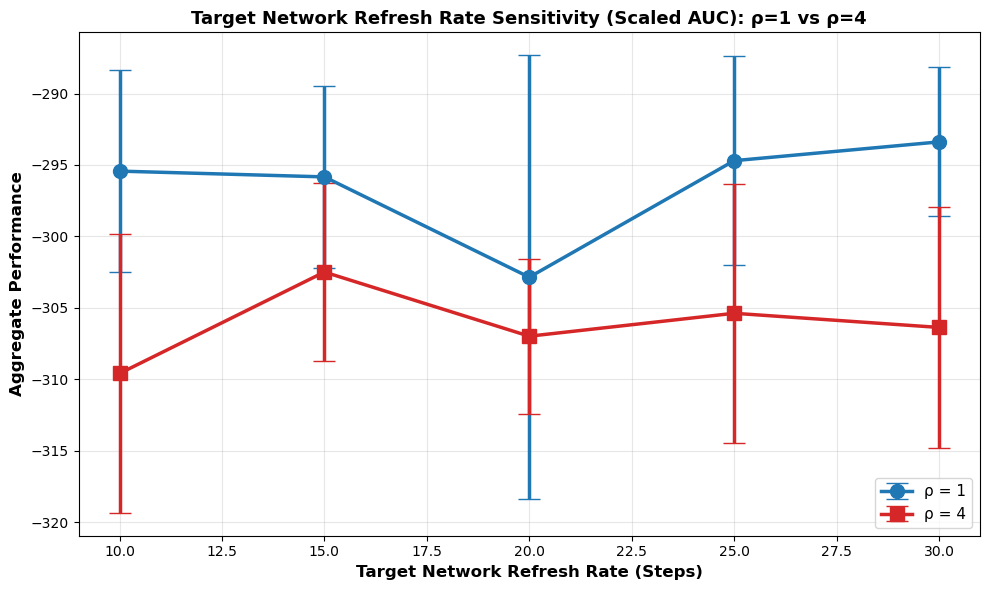

{1: {'means': [-295.4319763183594,
   -295.8360595703125,
   -302.8577880859375,
   -294.70135498046875,
   -293.38690185546875],
  'cis': [7.092679013185458,
   6.378339882279973,
   15.538089547342512,
   7.326369159721912,
   5.220248219594497],
  'stds': [12.807720184326172,
   11.517790794372559,
   28.05815887451172,
   13.229710578918457,
   9.42654800415039],
  'step_sizes': [10, 15, 20, 25, 30]},
 4: {'means': [-309.5963439941406,
   -302.49615478515625,
   -306.98687744140625,
   -305.38262939453125,
   -306.37213134765625],
  'cis': [9.75414899016842,
   6.228049504779324,
   5.428191030095378,
   9.063633981641784,
   8.441481267010476],
  'stds': [17.613712310791016,
   11.2464017868042,
   9.802043914794922,
   16.366804122924805,
   15.243342399597168],
  'step_sizes': [10, 15, 20, 25, 30]}}

In [122]:
import matplotlib.pyplot as plt
from scipy.stats import sem, t

def plot_sensitivity_refresh_rates(
    target_net_results,
    step_sizes,
    rhos=[1, 4],
    confidence=0.95,
    window_size=10,
    title="Target Network Refresh Rate Sensitivity",
    ylabel="Aggregate Performance",
):

    
    results = {rho: {"means": [], "cis": [], "stds": [], "step_sizes": []} for rho in rhos}



    for rho in rhos:
        
        for step_size in step_sizes:
            # Get trajectories for this rho and step_size
            
            aggregate_scores = []
            
            # Compute scaled AUC for each seed (smoothing + AUC aggregation)
            for seed, trajectory in target_net_results[rho][step_size]:
                # Convert to numpy array if needed
                r = np.asarray(trajectory, dtype=np.float32)
                
                if len(r) < window_size:
                    # If trajectory too short, use simple mean
                    scaled_auc = float(np.mean(r))
                else:
                    # Smooth trajectory
                    r_smooth = np.convolve(r, np.ones(window_size) / window_size, mode="valid")
                    n = len(r_smooth)
                    
                    if n == 0:
                        continue
                    elif n == 1:
                        scaled_auc = float(r_smooth[0])
                    else:
                        # Compute AUC using trapezoid rule
                        x = np.arange(n, dtype=np.float32)
                        auc = np.trapezoid(r_smooth, x)
                        scaled_auc = float(auc / n)
                
                aggregate_scores.append(scaled_auc)
            

            aggregate_scores = np.asarray(aggregate_scores, dtype=np.float32)
            mean_score = float(np.mean(aggregate_scores))
            std_dev = float(np.std(aggregate_scores, ddof=1))
            num_seeds = len(aggregate_scores)

            # Compute confidence interval
            if len(aggregate_scores) > 1:
                se = sem(aggregate_scores)
                t_crit = t.ppf((1 + confidence) / 2.0, df=len(aggregate_scores) - 1)
                ci = float(se * t_crit)
            else:
                ci = 0.0

            results[rho]["means"].append(mean_score)
            results[rho]["cis"].append(ci)
            results[rho]["stds"].append(std_dev)
            results[rho]["step_sizes"].append(step_size)
            

    # Create plot
    fig, ax = plt.subplots(figsize=(10, 6))

    for rho, marker, color in zip(rhos, ["o", "s"], ["tab:blue", "tab:red"]):
        means = results[rho]["means"]
        cis = results[rho]["cis"]
        step_sizes_plot = results[rho]["step_sizes"]

        ax.errorbar(
            step_sizes_plot,
            means,
            yerr=cis,
            marker=marker,
            capsize=8,
            markersize=10,
            linewidth=2.5,
            label=f"ρ = {rho}",
            color=color,
        )

    ax.set_xlabel("Target Network Refresh Rate (Steps)", fontsize=12, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=12, fontweight='bold')
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
               
    
    return results


# Plot sensitivity for available step sizes
step_sizes_rho1 = sorted(target_net_results[1].keys())
step_sizes_rho4 = sorted(target_net_results[4].keys())
step_sizes_all = sorted(set(step_sizes_rho1 + step_sizes_rho4))

plot_sensitivity_refresh_rates(
    target_net_results=target_net_results,
    step_sizes=step_sizes_all,
    rhos=[1, 4],
    confidence=0.95,
    window_size=10,
    title="Target Network Refresh Rate Sensitivity (Scaled AUC): ρ=1 vs ρ=4",
    ylabel="Aggregate Performance"
)